In [267]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import epsilon_0, pi, k

In [268]:
# charge
q = 1.0e-6

# coulomb's constant
k = 1/(4*pi*epsilon_0)

In [269]:
# positions
xp = 0.05
yp = 0
xn = -0.05
yn = 0

# grid limits
xmax = 0.2
ymax = 0.2
xmin = -0.2
ymin = -0.2

# resoltion
Nx = 101
Ny = 101

In [270]:
# create arrays
x_arr = np.linspace(xmin, xmax, Nx)
y_arr = np.linspace(ymin, ymax, Ny)
X, Y = np.meshgrid(x_arr, y_arr)

In [271]:
# meshgrid of distances to positive charge
rp = np.sqrt((X-xp)**2 + (Y-yp)**2)

# meshgrid of distances to negative charge
rn = np.sqrt((X-xn)**2 + (Y-yn)**2)

# find voltage at every point
V = k*q/rp - k*q/rn

In [272]:
# grid spacing
dx = x_arr[1] - x_arr[0]
dy = y_arr[1] - y_arr[0]

# initialize with nan
Ex = np.full_like(V, np.nan)
Ey = np.full_like(V, np.nan)

In [273]:
# central differences on interior points (not the sides)
# axis 1 = x (columns), axis 0 = y (rows)
Ex[1:-1, 1:-1] = -(V[1:-1, 2:] - V[1:-1, :-2]) / (2*dx) # V(x+dx) - V(x-dx)
Ey[1:-1, 1:-1] = -(V[2:, 1:-1] - V[:-2, 1:-1]) / (2*dy) # V(y+dy) - V(y-dy)

In [274]:
# flatten every 2D grid into one column each: one row per grid point
data = np.column_stack([X.ravel(), Y.ravel(), V.ravel(), Ex.ravel(), Ey.ravel()])

# write CSV
np.savetxt("dipole_field.csv", data, delimiter=",",
           header="x_m,y_m,V_volts,Ex_V_per_m,Ey_V_per_m", fmt="%.8e")
print(data.shape)

(10201, 5)


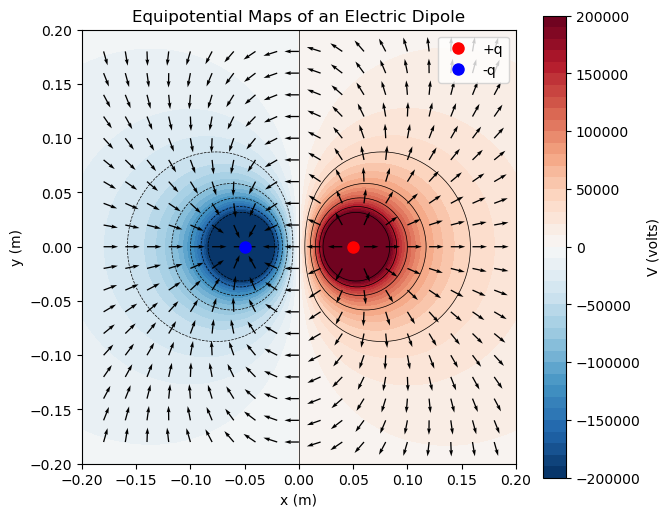

In [275]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

# V diverges at the charges, so clip the contour levels to a fixed range
Vmax = 2e5
levels = np.linspace(-Vmax, Vmax, 41)
cf = ax.contourf(X, Y, np.clip(V, -Vmax, Vmax), levels=levels, cmap="RdBu_r")
ax.contour(X, Y, V, levels=levels[::4], colors="k", linewidths=0.5)
fig.colorbar(cf, ax=ax, label="V (volts)")

# field arrows: every x points, normalized to unit length so direction is readable
max_arrows = 20 # number of arrows in x/y to show
s = int(max(Nx, Ny)/max_arrows)
Emag = np.hypot(Ex, Ey)
ax.quiver(X[::s, ::s], Y[::s, ::s], (Ex/Emag)[::s, ::s], (Ey/Emag)[::s, ::s],
          color="k", scale=30, width=0.003)

# mark the charges
ax.plot(xp, yp, "o", color="red", ms=8, label="+q")
ax.plot(xn, yn, "o", color="blue", ms=8, label="-q")

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Equipotential Maps of an Electric Dipole")
ax.set_aspect("equal")
ax.legend(loc="upper right")
fig.savefig("dipole_plot.png", dpi=150, bbox_inches="tight")
plt.show()